In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import fashion_mnist

In [16]:
# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Class names
class_names = [
    "T-shirt/Top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"
]

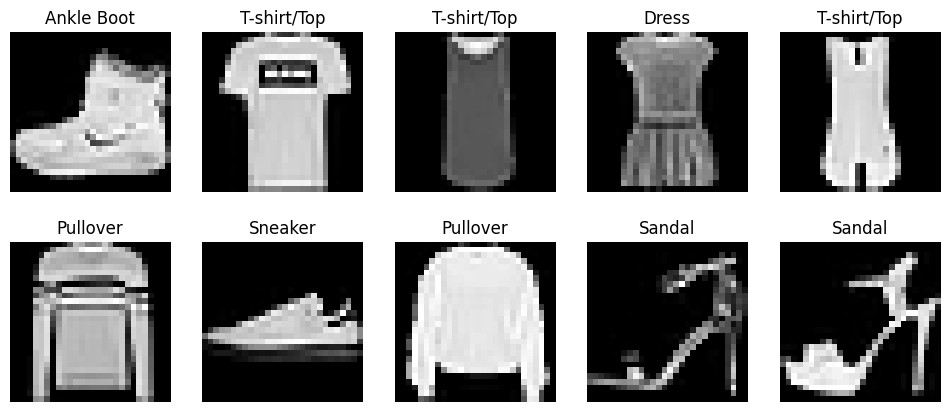

In [17]:
# Display sample images
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.show()

In [18]:
# Preprocess dataset
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [19]:
# Build CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

In [20]:
# Compile model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# Train model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 37ms/step - accuracy: 0.8328 - loss: 0.4581 - val_accuracy: 0.8701 - val_loss: 0.3669
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8855 - loss: 0.3095 - val_accuracy: 0.8858 - val_loss: 0.3144
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - accuracy: 0.9043 - loss: 0.2610 - val_accuracy: 0.8988 - val_loss: 0.2684
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 18ms/step - accuracy: 0.9165 - loss: 0.2257 - val_accuracy: 0.9019 - val_loss: 0.2722
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9267 - loss: 0.1977 - val_accuracy: 0.9055 - val_loss: 0.2689
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9344 - loss: 0.1770 - val_accuracy: 0.9125 - val_loss: 0.2565
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9426 - loss: 0.1562 - val_accuracy: 0.9121 - val_loss: 0.2612
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9482 -

In [22]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.2862468659877777
Test Accuracy: 0.9169999957084656


In [23]:
# Predictions
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


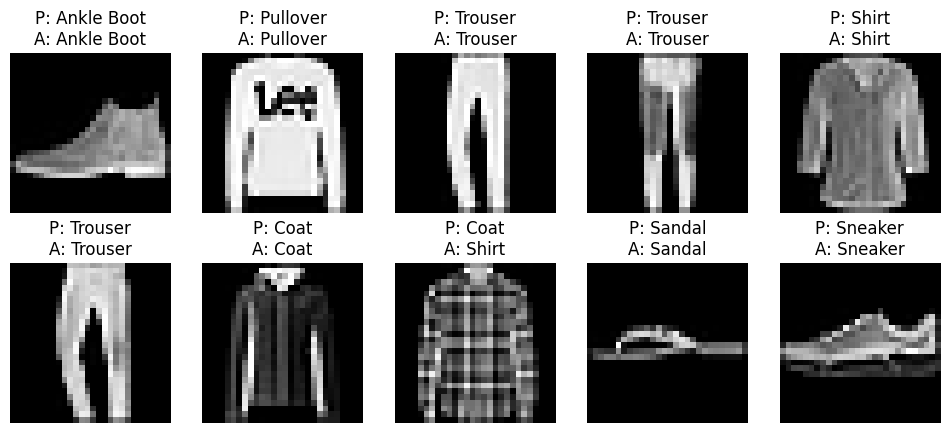

In [24]:
# Display predicted and actual labels
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title(f"P: {class_names[predicted_labels[i]]}\nA: {class_names[y_test[i]]}")
    plt.axis("off")
plt.show()

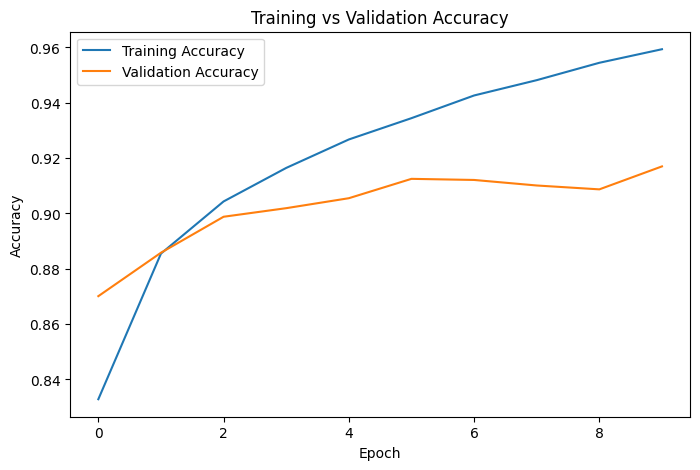

In [25]:
# Plot training and validation accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

<Figure size 1000x800 with 0 Axes>

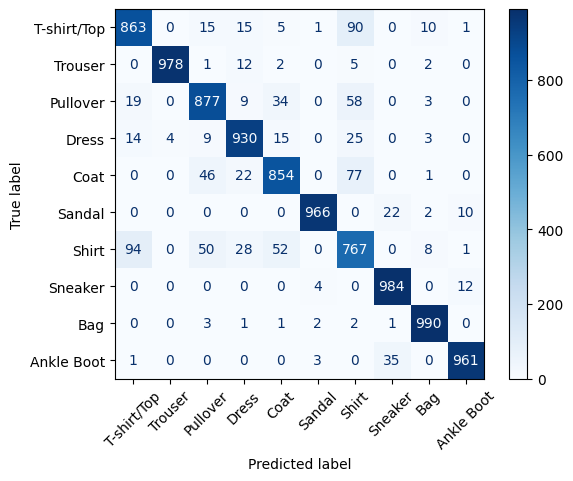

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, predicted_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

plt.figure(figsize=(10,8))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()

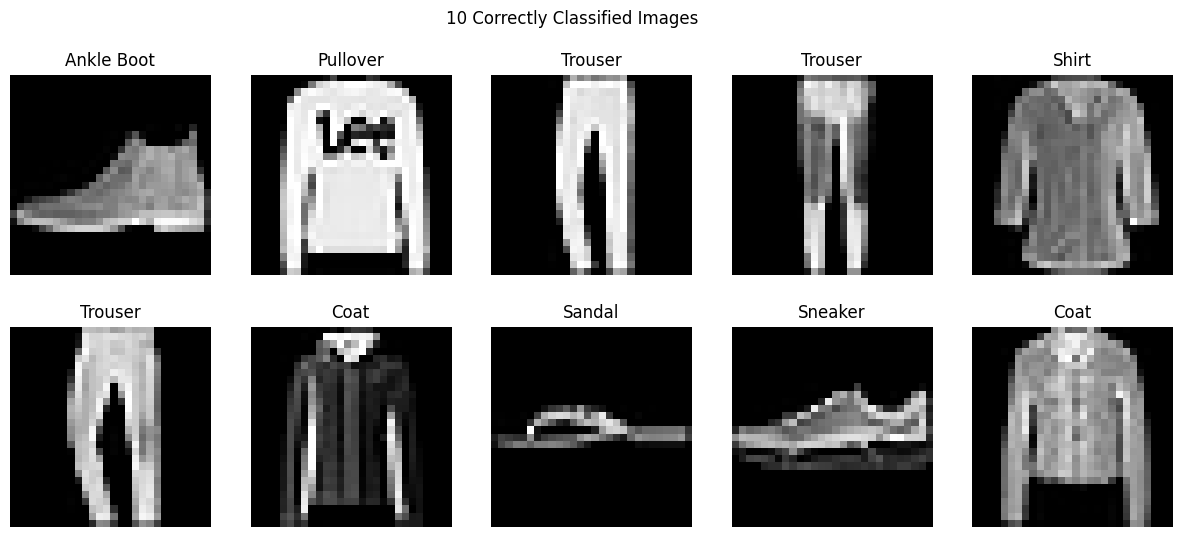

In [27]:
# Correctly classified images
correct = np.where(predicted_labels == y_test)[0]

plt.figure(figsize=(15,6))
for i, idx in enumerate(correct[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap="gray")
    plt.title(class_names[predicted_labels[idx]])
    plt.axis("off")
plt.suptitle("10 Correctly Classified Images")
plt.show()

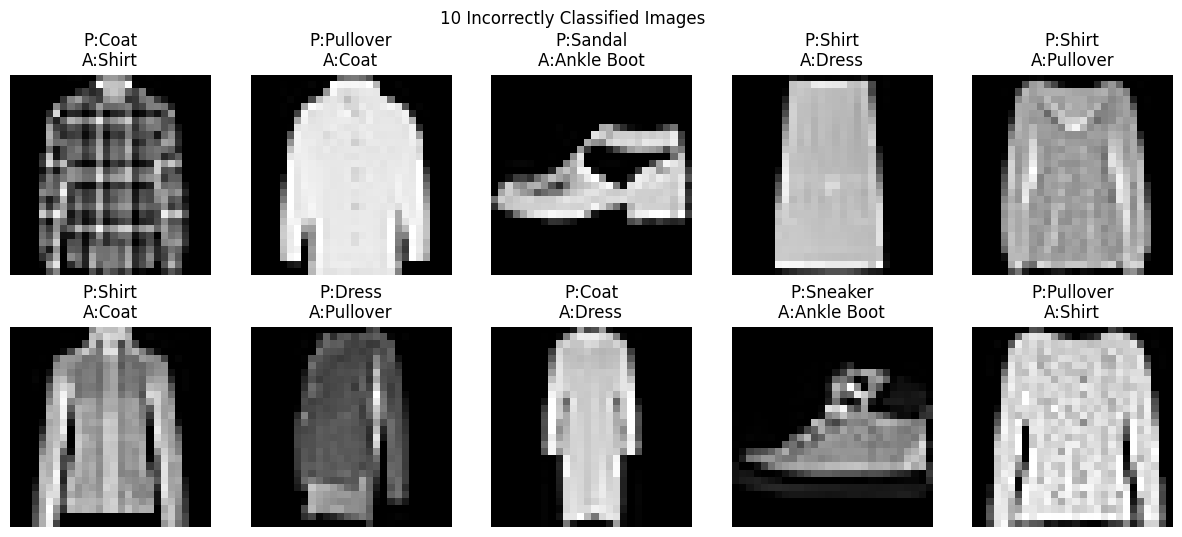

In [28]:
# Incorrectly classified images
incorrect = np.where(predicted_labels != y_test)[0]

plt.figure(figsize=(15,6))
for i, idx in enumerate(incorrect[:10]):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[idx].reshape(28,28), cmap="gray")
    plt.title(f"P:{class_names[predicted_labels[idx]]}\nA:{class_names[y_test[idx]]}")
    plt.axis("off")
plt.suptitle("10 Incorrectly Classified Images")
plt.show()